# NiCo-Wrapper Vignette — Interactive exploration of the nico-wrapper pipeline

This notebook shows you how to explore in an interactive session the outputs of the nico analysis. It is intended to be used after running succesfully the basic nico-wrapper pipeline, which could have been run with the CLI interface or with a different notebook.

This notebook takes the results from the label transfer (for cell annotation), niche interaction analysis and covariation analysis and it allows you to:
- Make plots of the different analysis steps
- Analysis of ligand-receptor interactions between interacting cells
- Functional enrichment analysis for genes associated with latent factors


## 1. Recap of the basic nico-wrapper pipeline:
 - Example with the basic CLI commands

```bash
#Defining input datasets
REFERENCE_H5AD="<path_to_ref_data/scRNAseq_data.h5ad>"
SPATIAL_H5AD="<path_to_spatial_data/spatial_data.h5ad>"

# Key column names
SPATIAL_KEY="spatial"    # .obsm key holding XY coordinates in the spatial file
REF_LABEL_KEY="cluster"    # .obs column holding cell-type labels in the reference data

uv run nico-preprocess build \
  --reference $REFERENCE_H5AD \
  --spatial $SPATIAL_H5AD \
  --ref-out-dir inputRef \
  --spatial-out-dir inputQuery \
  --spatial-key $SPATIAL_KEY \
  --ref-label-key $REF_LABEL_KEY \

uv run nico-transfer run \
  --ref-dir inputRef \
  --spatial-dir inputQuery \
  --output-dir nico_analysis

uv run nico-niche run \
  --output-dir nico_analysis

uv run nico-covariation run \
  --output-dir nico_analysis \
  --ref-dir inputRef \
  --spatial-dir inputQuery
```



 - Brief explanation of each command:
1. `nico-preprocess build` — Preprocesses and normalizes the reference and spatial datasets, writing outputs to `inputRef/` and `inputQuery/`.
2. `nico-transfer run` — Transfers cell-type labels from the reference to spatial cells, saving results to `nico_analysis/`.
3. `nico-niche run` — Runs niche prediction (identifying spatial neighborhoods/niches) using the `nico_analysis/` directory.
4. `nico-covariation run` — Analyzes gene co-variation within niches, using both the analysis directory and the preprocessed input files.


**Note**

In order to run this notebook on jupyter, install also `notebook` and `jupyter` packages into your environment

```bash
pip install notebook jupyter
```

## 2. Loading Results

Variables created by the cell below:

| Variable | How it is restored |
|---|---|
| `niche_result` | `load_niche_result()` — reads from disk, no recomputation |
| `covariation_result` | `load_covariation_result()` — reads from disk, no recomputation |
| `transfer_outputs` | Manually reconstructed as a `TransferOutputs` dataclass from known paths |
| `interaction_table_path` | Re-exported from `niche_result` (file already on disk, very fast) |
| `regression_table_path` | Re-exported from `covariation_result` (file already on disk, very fast) |

In [ ]:
from pathlib import Path
from nico_wrapper.niche import load_niche_result, export_interaction_table
from nico_wrapper.niche.proximity import run_proximity_analysis
from nico_wrapper.niche.config import ProximityConfig
from nico_wrapper.covariation import load_covariation_result, export_regression_table
from nico_wrapper.transfer.config import TransferOutputs

# ── Output directories (must match what was used when the pipeline ran) ───────
ANALYSIS_DIR    = Path("working_dir/nico_analysis")
REF_OUT_DIR     = Path("working_dir/inputRef")
SPATIAL_OUT_DIR = Path("working_dir/inputQuery")

# ── Pipeline parameters (must match the original run) ─────────────────────────
SPATIAL_KEY = "spatial"
RADIUS      = 0
N_FACTORS   = 3

# ── 1. Niche interaction result ───────────────────────────────────────────────
niche_result = load_niche_result(ANALYSIS_DIR, radius=RADIUS)
print(f"niche_result loaded: prediction_dir = {niche_result.prediction_dir}")

# ── 2. Interaction table (already on disk; re-export is instant) ───────────────
interaction_table_path = export_interaction_table(
    niche_result,
    cutoff=0.0,
    include_self_edges=True,
)
print(f"interaction_table_path: {interaction_table_path}")

# ── 3. Covariation result ─────────────────────────────────────────────────────
covariation_result = load_covariation_result(
    ANALYSIS_DIR,
    radius=RADIUS,
    n_factors=N_FACTORS,
    load_state=True,   # loads the NiCo state pickle so report functions work
)
print(f"covariation_result loaded: covariation_dir = {covariation_result.covariation_dir}")

# ── 4. Regression table (already on disk; re-export is instant) ───────────────
regression_table_path = export_regression_table(covariation_result)
print(f"regression_table_path: {regression_table_path}")

# ── 5. Transfer outputs (no serialiser exists — reconstruct from known paths) ─
_annotation_dir = ANALYSIS_DIR / "annotations"
_annotated_h5ad = ANALYSIS_DIR / "nico_celltype_annotation.h5ad"

transfer_outputs = TransferOutputs(
    output_dir=ANALYSIS_DIR,
    annotation_dir=_annotation_dir,
    annotated_h5ad=_annotated_h5ad,
    anchors_npz=None,
    iteration_cluster_csvs=tuple(sorted(_annotation_dir.glob("iteration_*_cluster*.csv"))) if _annotation_dir.exists() else (),
    iteration_celltype_csvs=tuple(sorted(_annotation_dir.glob("iteration_*_celltype*.csv"))) if _annotation_dir.exists() else (),
)
print(f"transfer_outputs.annotated_h5ad: {transfer_outputs.annotated_h5ad}")

print("\nAll variables are ready.")

niche_result loaded: prediction_dir = /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear
interaction_table_path: /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/interactions_0.tsv
covariation_result loaded: covariation_dir = /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3
regression_table_path: /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/regression_coefficients.tsv
transfer_outputs.annotated_h5ad: /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/nico_celltype_annotation.h5ad

All previous variables are ready.


## 3. Visualization

The cells below produce complementary visualisations to help you interpret the results, based on different steps of the analysis

- Spatial and UMAP plots
- Niche Interaction plots
- Covariation analysis plots

### Spatial and UMAP plots

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/annotations/tissue_and_umap_with_all_celltype_annotations.pdf


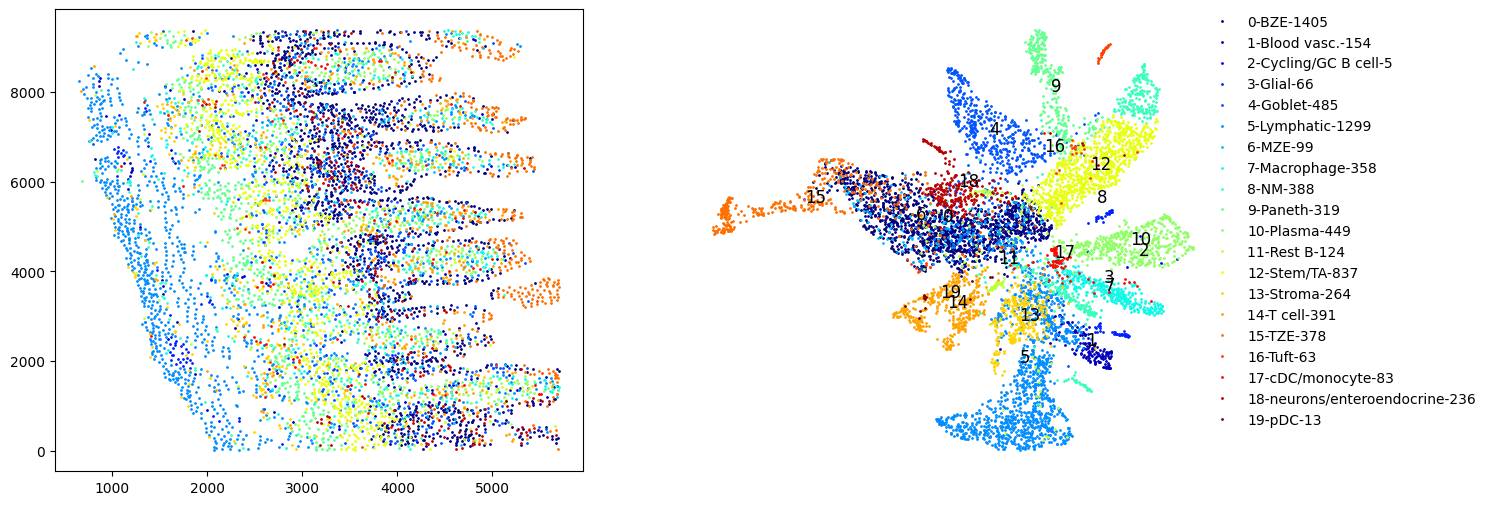

In [ ]:
#General cell type localization in the spatial slide and UMAP
import nico
from nico import Annotations as sann

sann.visualize_umap_and_cell_coordinates_with_all_celltypes(
    output_nico_dir=str(transfer_outputs.output_dir) + "/",
    output_annotation_dir=str(transfer_outputs.annotation_dir) + "/",
    anndata_object_name=transfer_outputs.annotated_h5ad.name,
    spatial_cluster_tag="nico_ct",
    spatial_coordinate_tag="spatial",
    umap_tag="X_umap",
    showit=True,
    transparent_mode=False,
)

[['Stem/TA', 'Paneth'], ['Paneth', 'Goblet']]
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/annotations/fig_individual_annotation/Stem_TA0.pdf
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/annotations/fig_individual_annotation/Paneth1.pdf


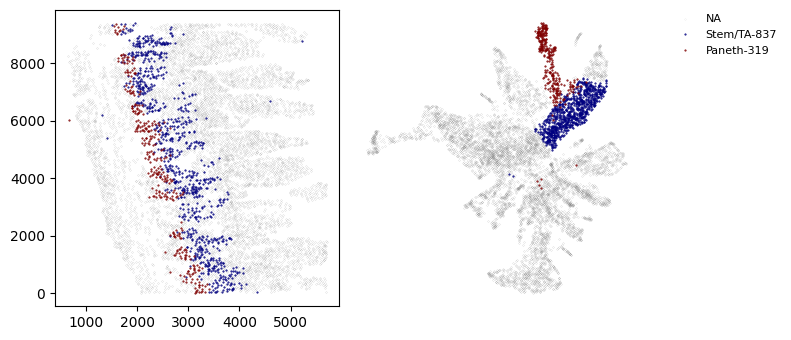

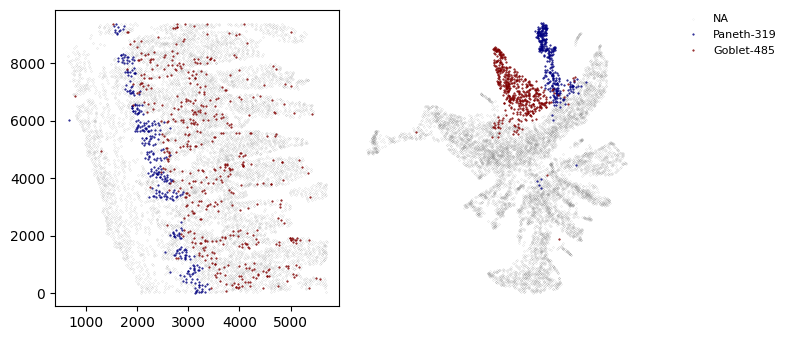

In [ ]:
#Visualize spatial annotation of specific cell types
choose_celltypes=[['Stem/TA','Paneth'],['Paneth','Goblet']]

sann.visualize_umap_and_cell_coordinates_with_selected_celltypes(
choose_celltypes=choose_celltypes,    
output_nico_dir=str(transfer_outputs.output_dir) + "/",
output_annotation_dir=str(transfer_outputs.annotation_dir) + "/",
anndata_object_name=transfer_outputs.annotated_h5ad.name,
spatial_cluster_tag="nico_ct",
spatial_coordinate_tag='spatial',
umap_tag='X_umap',
showit=True,transparent_mode=False)

### Interaction plots

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/Niche_interactions_without_edge_weights_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/Niche_interactions_without_edge_weights_R0.pdf')]

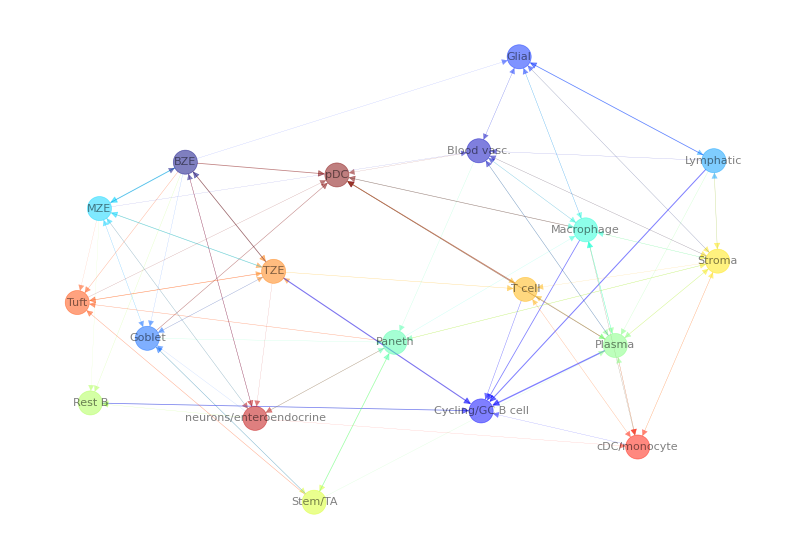

In [ ]:
#Cell-type interactions within the niche
# Plot the niche interaction network without edge weights
# Uses plot_niche_result with kind="graph", which calls sint.plot_niche_interactions_without_edge_weight internally.

from nico_wrapper.niche import NichePlotConfig
from nico_wrapper.niche.plotting import plot_niche_result, _to_nico_plot_namespace

plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("graph",),
        interaction_cutoff=0.1,
        graph_edge_labels=False,   # True → show coefficient values on edges
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/Niche_interactions_with_edge_weights_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/Niche_interactions_with_edge_weights_R0.pdf')]

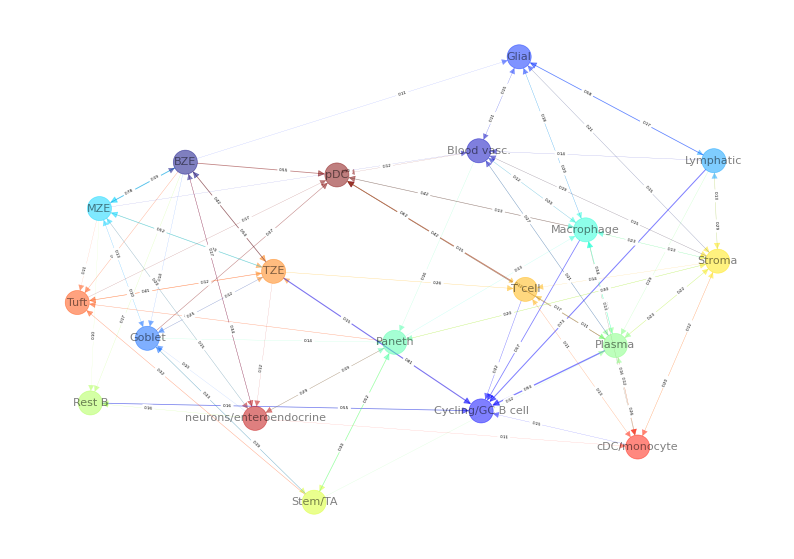

In [ ]:
# Plot the niche interaction network with edge weights
# Set graph_edge_labels=True
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("graph",),
        interaction_cutoff=0.1,
        graph_edge_labels=True,   # True → show coefficient values on edges
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/TopCoeff_R0/Rank1_Paneth.pdf
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/TopCoeff_R0/Rank3_Stem_TA.pdf


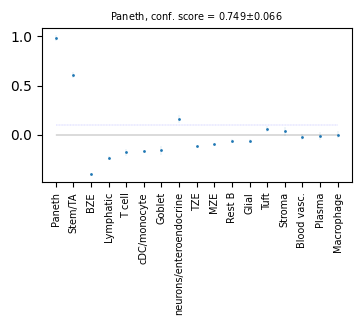

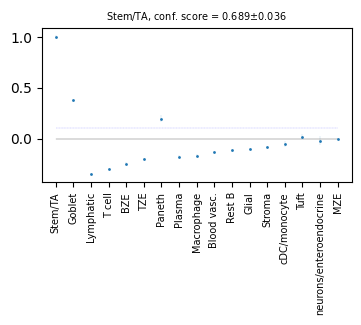

In [ ]:
# Interaction coefficients for selected source cell types
from nico_wrapper.niche import NichePlotConfig
from nico_wrapper.niche.plotting import plot_niche_result, _to_nico_plot_namespace

celltype_niche_interaction_cutoff = 0.1

# plot_niche_result supports choose_celltypes for the "top-coefficients" kind.
# Pass an empty tuple (default) to plot all cell types, or list specific ones to filter.

# Option A — all cell types
#plot_niche_result(
#    niche_result,
#    config=NichePlotConfig(
#        kinds=("top-coefficients",),
#        interaction_cutoff=celltype_niche_interaction_cutoff,
#        show=True,
#    ),
#)

# Option B — selected cell types only
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("top-coefficients",),
        interaction_cutoff=celltype_niche_interaction_cutoff,
        choose_celltypes=("Stem/TA", "Paneth"),   # ← leave empty tuple for all
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/Confusing_matrix_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/Confusing_matrix_R0.pdf')]

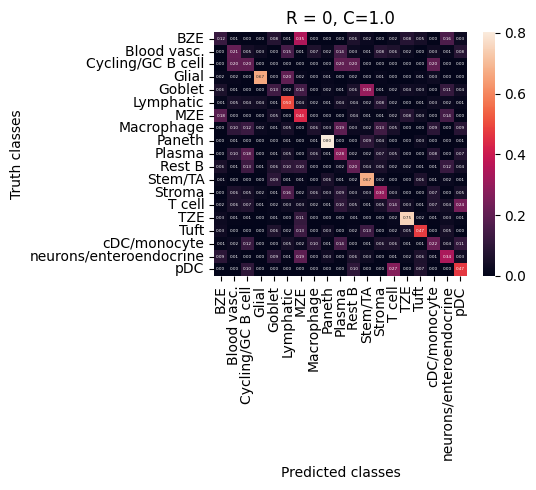

In [ ]:
# Plot the average confusion matrix of the classifier from cross-folds
#It compares the predicted cell type label of the logistic regression with the ground truth label corresponding to the NiCo annotation
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("confusion",),
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/weight_matrix_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/weight_matrix_R0.pdf')]

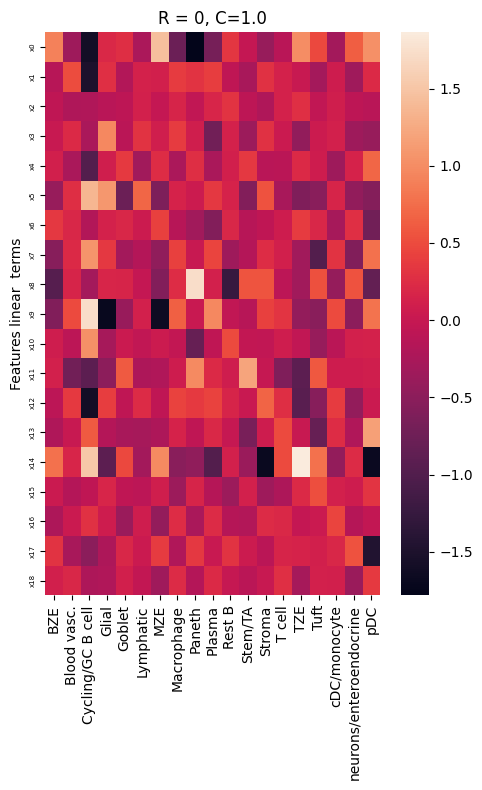

In [ ]:
# Plot the average coefficient matrix of the classifier from cross-folds
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("coefficients",),
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/scores_0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/niche_prediction_linear/scores_0.pdf')]

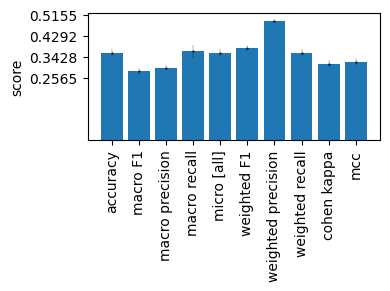

In [ ]:
# Plot the evaluation score of the classifier for different metrics
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("scores",),
        show=True,
    ),
)

Observed pairs table : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/proximity_observed_0.tsv
Obs/rand ratio table : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/proximity_ratio_0.tsv
Plot saved to        : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/celltype_proximity_pairs0.png


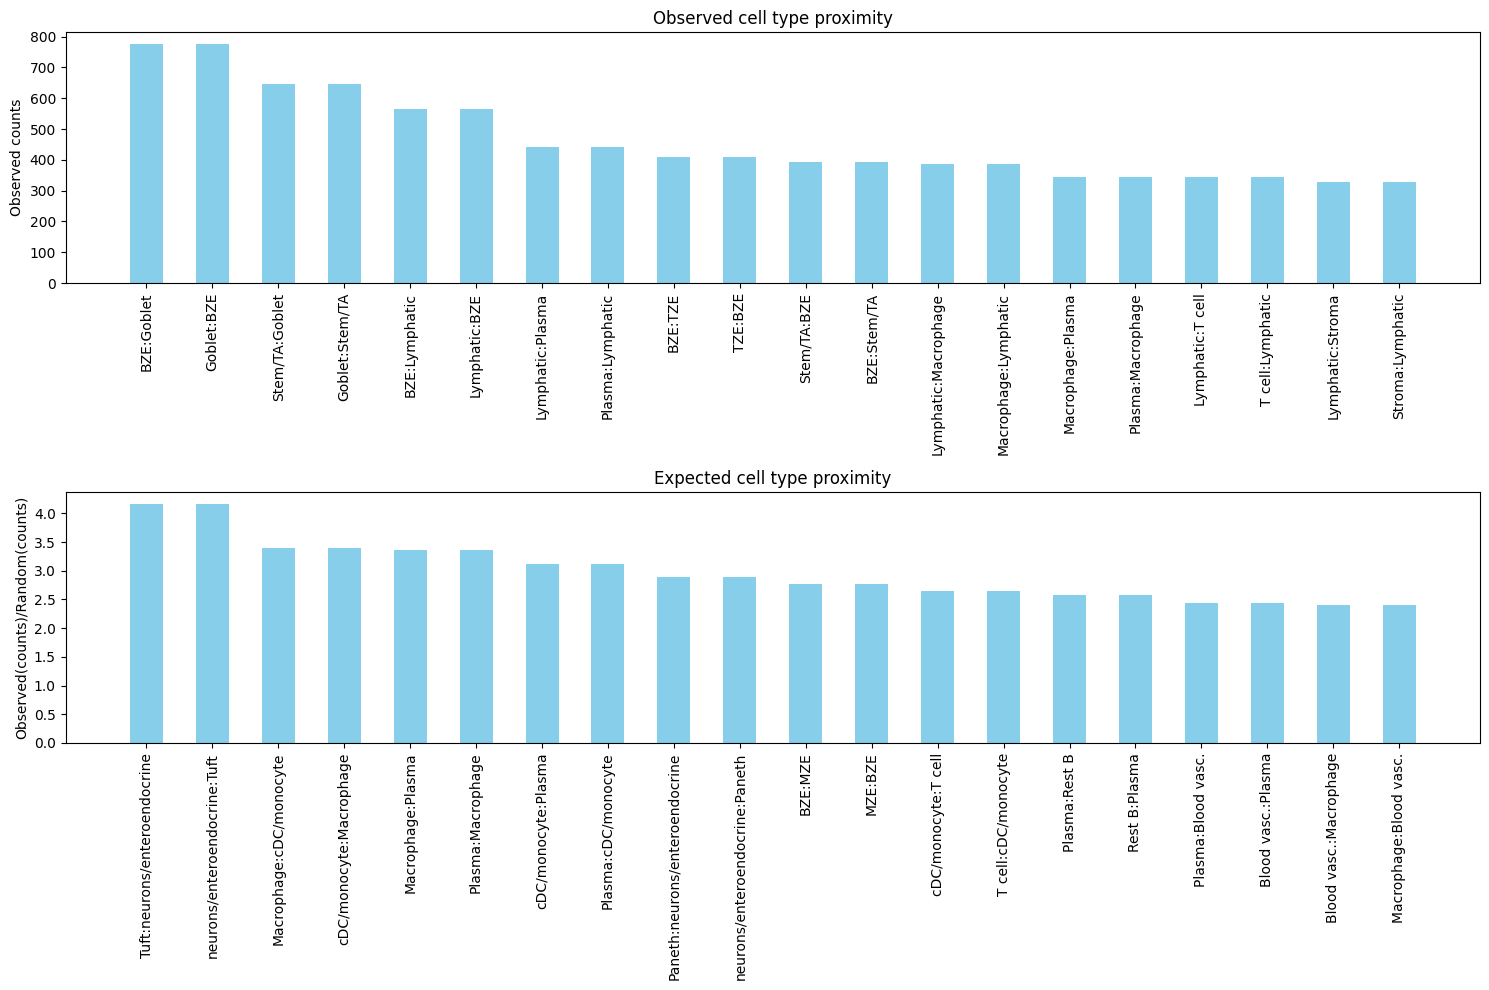

In [ ]:
# Proximity analysis between cell types
from nico_wrapper.niche import ProximityConfig
from nico_wrapper.niche.proximity import run_proximity_analysis

# Visualization of top co-localized cell-type pairs (observed vs. randomized)
proximity_result = run_proximity_analysis(
    niche_result,
    config=ProximityConfig(
        n_permutations=1000,       # number of random permutations for the null distribution
        remove_self_pairs=True,    # exclude same cell-type pairs
        as_counts=True,            # use raw counts (False = use proportions)
        seed=42,                   # for reproducibility
        saveas="png",
        show=True,                 # display the NiCo proximity bar chart inline
    ),
)

print(f"Observed pairs table : {proximity_result.observed_tsv}")
print(f"Obs/rand ratio table : {proximity_result.ratio_tsv}")
print(f"Plot saved to        : {proximity_result.plot_path}")

### Covariation analysis plots

cell types found  ['Paneth']
The figures are saved:  nico_analysis/covariations_R0_F3/NMF_output/Paneth.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/NMF_output/Paneth.png'),)

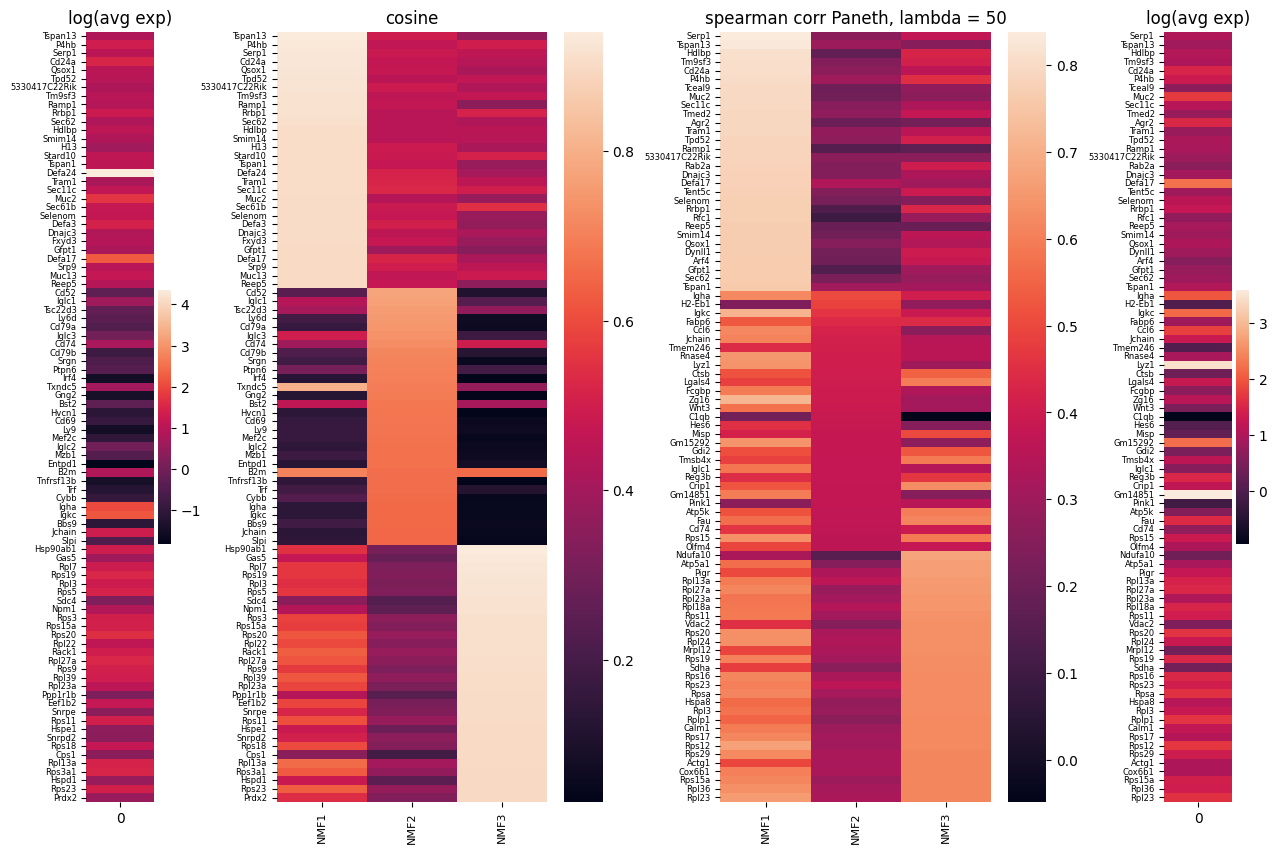

In [ ]:
from nico_wrapper.covariation.reports import plot_factor_gene_heatmaps
from nico_wrapper.covariation.config import CovariationReportConfig

# Plot cosine and Spearman correlation to factors for selected cell types
# plot_factor_gene_heatmaps wraps scov.plot_cosine_and_spearman_correlation_to_factors
plot_factor_gene_heatmaps(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Paneth",),   # ← cell types to plot; empty tuple = all
        top_genes_per_factor=30,        # NOG_Fa: number of top genes per factor
        correlation_with_spearman=True, # True = Spearman; False = cosine only
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

The figures are saved:  nico_analysis/covariations_R0_F3/dotplots/Factors_Stem_TA.png


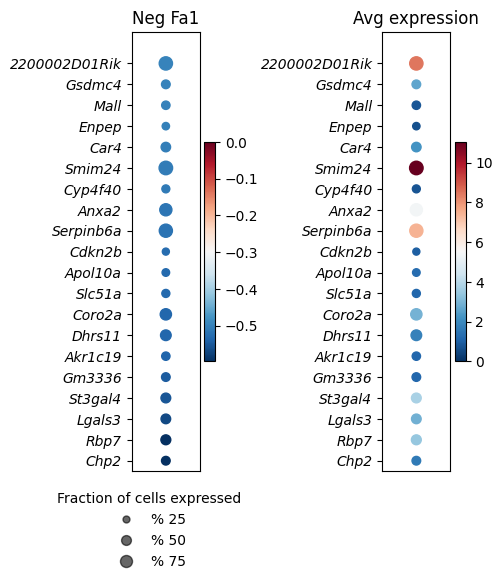

In [ ]:
#Visualizing genes associated with the latent factors along with average expression
from nico_wrapper.covariation.reports import extract_top_genes
from nico_wrapper.covariation.config import CovariationReportConfig

# Extract and plot top genes for a single cell type / factor combination.
# Returns a DataFrame; also saves a TSV next to the covariation outputs.
top_genes_df = extract_top_genes(
    covariation_result,
    cell_type="Stem/TA",
    factor_id=1,
    config=CovariationReportConfig(
        top_genes_per_factor=20,
        organism="Mouse",
        include_rps_rpl_mt_genes=True,
        correlation_with_spearman=True,
        positively_correlated=False,
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

#The top genes are also saved to a TSV file next to the covariation outputs

In [ ]:
#Inspect genes associated with a latent factor
#The table summarizes the positive or negative spearman correlation or cosine similarity with the
# factor, the mean expression and the proportion of cells expressing the gene for the respective cell type.
top_genes_df

,Gene,Fa,mean_expression,proportion_of_population_expressed
0,Chp2,-0.597569,1.619048,0.388095
1,Rbp7,-0.596592,3.402381,0.504762
2,Lgals3,-0.568359,2.847619,0.480952
3,St3gal4,-0.553810,3.750000,0.492857
4,Gm3336,-0.547385,1.152381,0.383333
5,Akr1c19,-0.539133,1.142857,0.359524
6,Dhrs11,-0.536353,1.773810,0.585714
7,Coro2a,-0.535430,2.904762,0.657143
8,Slc51a,-0.531252,1.123810,0.333333
9,Apol10a,-0.530303,1.271429,0.297619


Plot linear regression coefficients between factors of the central cell type (y-axis) and factors of niche cell types (x-axis).

Circle size scales with -log10(p-value) (indicated as number on top of each circle). To generate plots for all cell types, leave list argument choose_celltypes empty.

cell types found  ['Stem/TA']
The regression figures as pvalue circle plots are saved in following path  nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_circleplot_*


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_circleplot_11_Stem_TA.png'),)

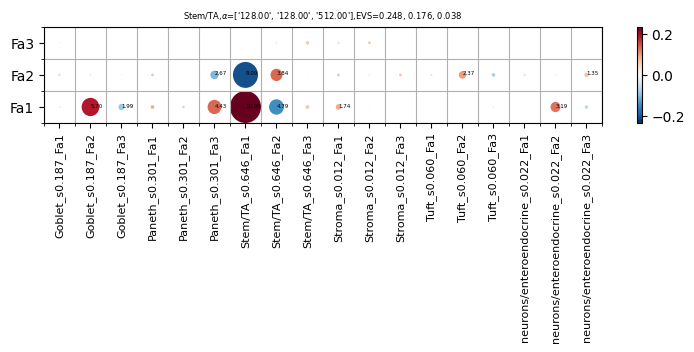

In [ ]:
from nico_wrapper.covariation.reports import plot_regression_covariations
from nico_wrapper.covariation.config import CovariationReportConfig

plot_regression_covariations(
    covariation_result,
    kind="circle",
    config=CovariationReportConfig(
        choose_celltypes=("Stem/TA",),
        pvalue_cutoff=0.05,
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_cirlce_sizebar.pdf'),)

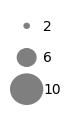

In [ ]:
from nico_wrapper.covariation.reports import print_pvalue_sizebar
from nico_wrapper.covariation.config import CovariationReportConfig

print_pvalue_sizebar(
    covariation_result,
    config=CovariationReportConfig(
        show=True,
        saveas="pdf",
        dpi=300,
        transparent=False,
    ),
)

cell types found  ['Stem/TA']
The regression figures as pvalue heatmap plots are saved in following path  nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_heatmap_*


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_heatmap_11_Stem_TA.png'),)

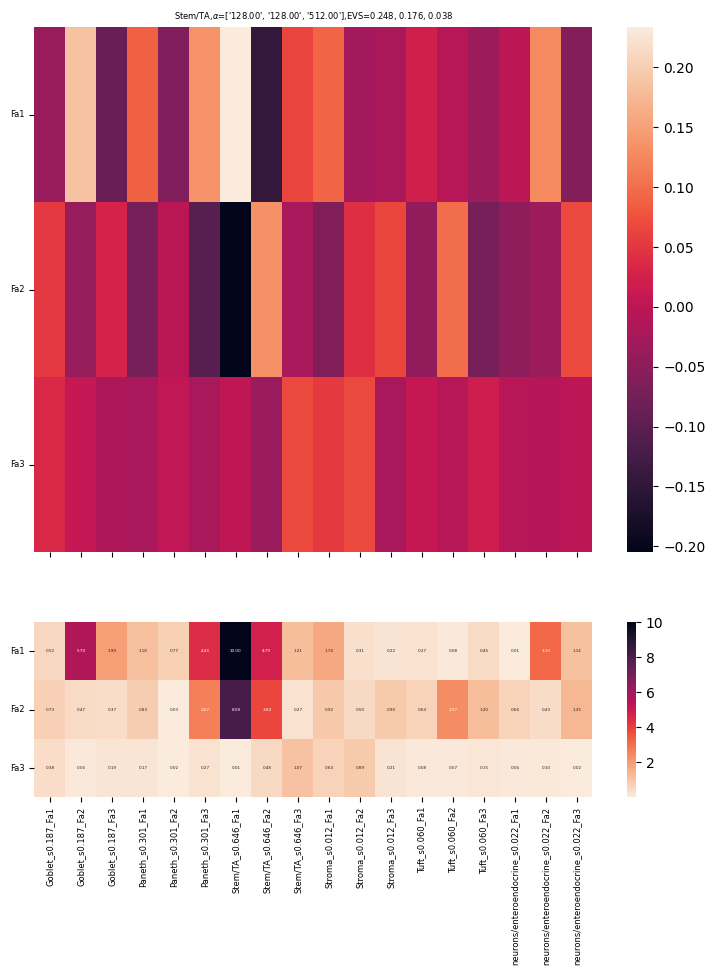

In [ ]:
from nico_wrapper.covariation.reports import plot_regression_covariations
from nico_wrapper.covariation.config import CovariationReportConfig

plot_regression_covariations(
    covariation_result,
    kind="heatmap",
    config=CovariationReportConfig(
        choose_celltypes=("Stem/TA",),
        dpi=300,
        show=True,
        saveas="png",
        transparent=False,
    ),
)

One of the main questions is what happens when the two cell types are colocalized versus when they are not.
Do the differential gene expression profiles differ between colocalized cells and non-colocalized cells?
NiCo answer this using plotting factor loadings (as bar plots or violin plots) for a cell type when it is colocalized versus when it is not.

Total number of colocalized celltype pairs 207
The figures are saved:  nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png'),)

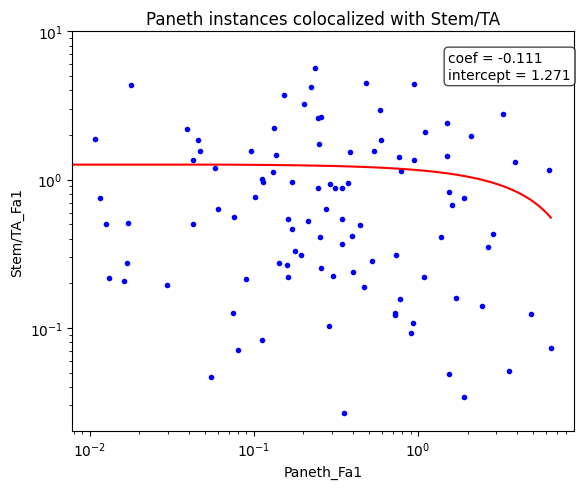

In [ ]:
from nico_wrapper.covariation.reports import plot_colocalized_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Visualize the change in factor loadings associated with colocalization between two cell types.
# Set include_bar=True and/or include_violin=True to generate all plots in a single call.
CC_name = "Paneth"
NC_name = "Stem/TA"
CC_factor_id = 1
#NC_factor_id = 2
NC_factor_id = 1

plot_colocalized_factors(
    covariation_result,
    central_cell_type=CC_name,
    neighbor_cell_type=NC_name,
    central_factor_id=CC_factor_id,
    neighbor_factor_id=NC_factor_id,
    include_bar=False,
    include_violin=False,
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

Total number of colocalized celltype pairs 207
The figures are saved:  nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png
The figures are saved:  nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_BarPlot.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_BarPlot.png'),)

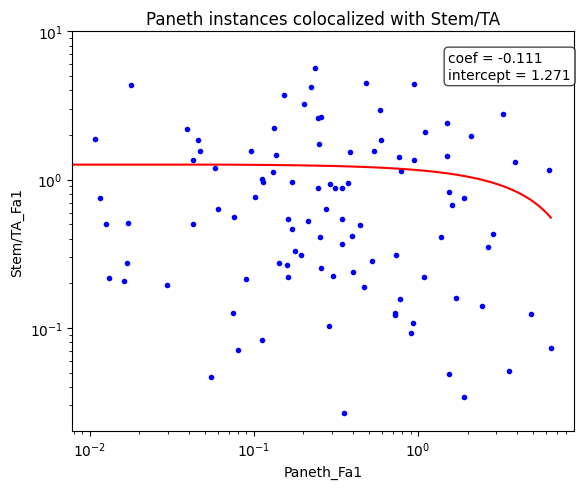

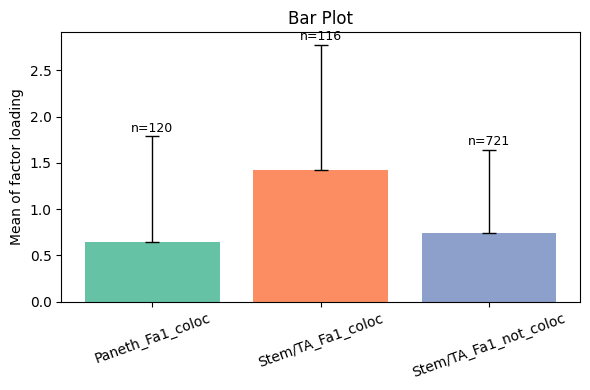

In [ ]:
from nico_wrapper.covariation.reports import plot_colocalized_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Bar plot: factor loadings of colocalized vs non-colocalized instances.
plot_colocalized_factors(
    covariation_result,
    central_cell_type=CC_name,
    neighbor_cell_type=NC_name,
    central_factor_id=CC_factor_id,
    neighbor_factor_id=NC_factor_id,
    include_bar=True,
    include_violin=False,
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

Total number of colocalized celltype pairs 207
The figures are saved:  nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png
The figures are saved:  nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_ViolinPlot.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/cli_test/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_ViolinPlot.png'),)

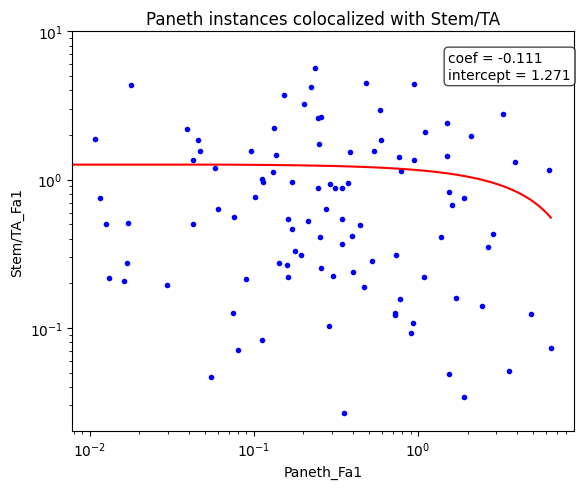

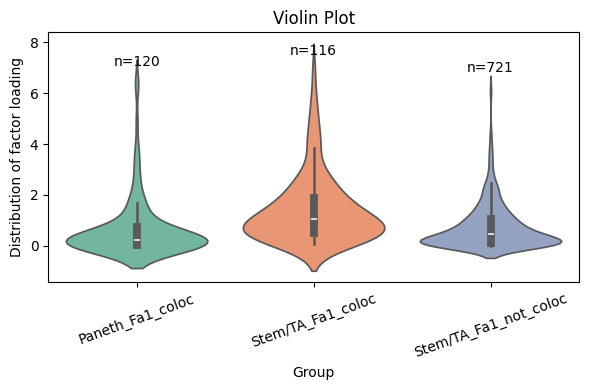

In [ ]:
from nico_wrapper.covariation.reports import plot_colocalized_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Violin plot: factor loadings of colocalized vs non-colocalized instances.
plot_colocalized_factors(
    covariation_result,
    central_cell_type=CC_name,
    neighbor_cell_type=NC_name,
    central_factor_id=CC_factor_id,
    neighbor_factor_id=NC_factor_id,
    include_bar=False,
    include_violin=True,
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

#### Analysis of ligand-receptor interactions
Take the ligand and receptor pairs that are covarying across interacting cell types and the factor loadings identified by the covariation analysis

In [ ]:
from nico_wrapper.covariation.reports import plot_ligand_receptor_interactions
from nico_wrapper.covariation.config import CovariationReportConfig
from IPython.display import display, Image

# Ligand-receptor analysis
# Analysis between Stem/TA and Paneth cells for factors 1 and 1.
lr_paths = plot_ligand_receptor_interactions(
    covariation_result,
    choose_interacting_celltype_pair=("Stem/TA", "Paneth"),
    choose_factors_id=(1,1),
    config=CovariationReportConfig(
        pvalue_cutoff=0.05,
        ligand_factor_threshold=0.1, #Default is 0.3
        receptor_factor_threshold=0.1, #Default is 0.3
        ligand_population_threshold=0.2,
        receptor_population_threshold=0.2,
        dpi=150,
        show=False,   # nico closes figures before Jupyter captures them; display from file instead
        saveas="png",
        transparent=False,
    ),
)

# Display the saved plots inline
for p in lr_paths:
    display(Image(filename=str(p)))

LR figures for both ways are saved in following path  nico_analysis/covariations_R0_F3/Plot_ligand_receptor_in_niche/
LR figures for CC to NC are saved in following path  nico_analysis/covariations_R0_F3/Plot_ligand_receptor_in_niche_cc_vs_nc/
LR figures for NC to CC are saved in following path  nico_analysis/covariations_R0_F3/Plot_ligand_receptor_in_niche_nc_vs_cc/


In [ ]:
# Option 2: perform ligand-receptor analysis for Paneth cells and all the significant interaction partners
lr_paths2 = plot_ligand_receptor_interactions(
    covariation_result,
    choose_interacting_celltype_pair=("Paneth"),
    #choose_interacting_celltype_pair=("Gobleth"),
    choose_factors_id=(),
    config=CovariationReportConfig(
        pvalue_cutoff=0.05,
        ligand_factor_threshold=0.1, #Default is 0.3
        receptor_factor_threshold=0.1, #Default is 0.3
        ligand_population_threshold=0.2,
        receptor_population_threshold=0.2,
        dpi=150,
        show=True,   # nico closes figures before Jupyter captures them; display from file instead
        saveas="png",
        transparent=False,
    ),
)

# Display the saved plots inline
for p in lr_paths2:
    display(Image(filename=str(p)))

LR figures for both ways are saved in following path  nico_analysis/covariations_R0_F3/Plot_ligand_receptor_in_niche/
LR figures for CC to NC are saved in following path  nico_analysis/covariations_R0_F3/Plot_ligand_receptor_in_niche_cc_vs_nc/
LR figures for NC to CC are saved in following path  nico_analysis/covariations_R0_F3/Plot_ligand_receptor_in_niche_nc_vs_cc/


#### Functional enrichment analysis for genes associated with latent factors

The pathway figures are saved in  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Pathway_figures/
cell types found  ['Stem/TA']


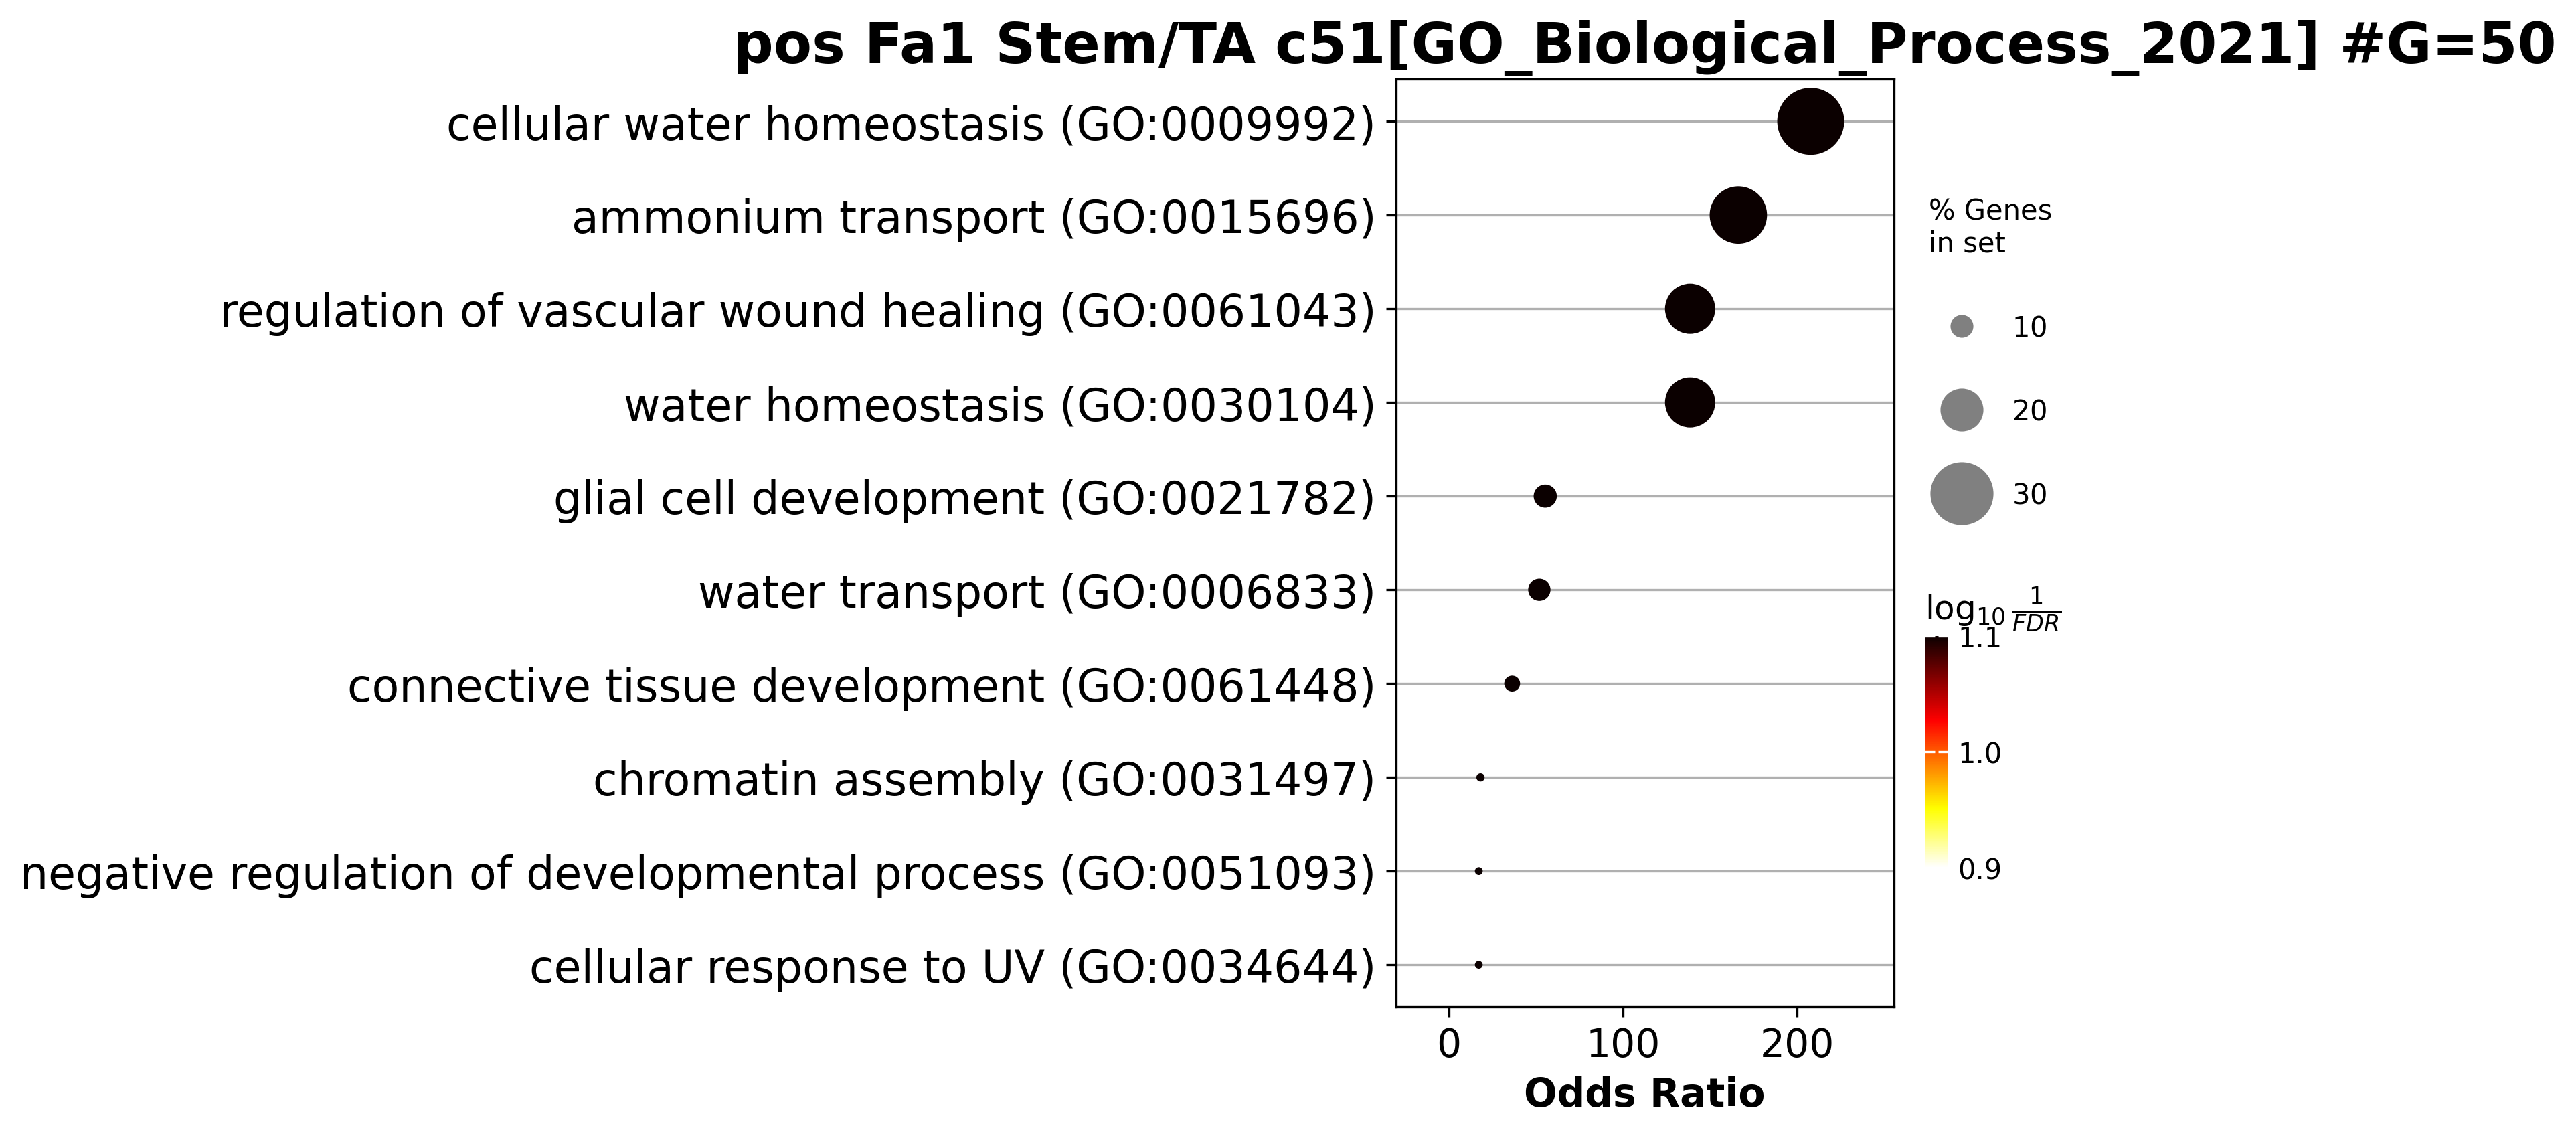

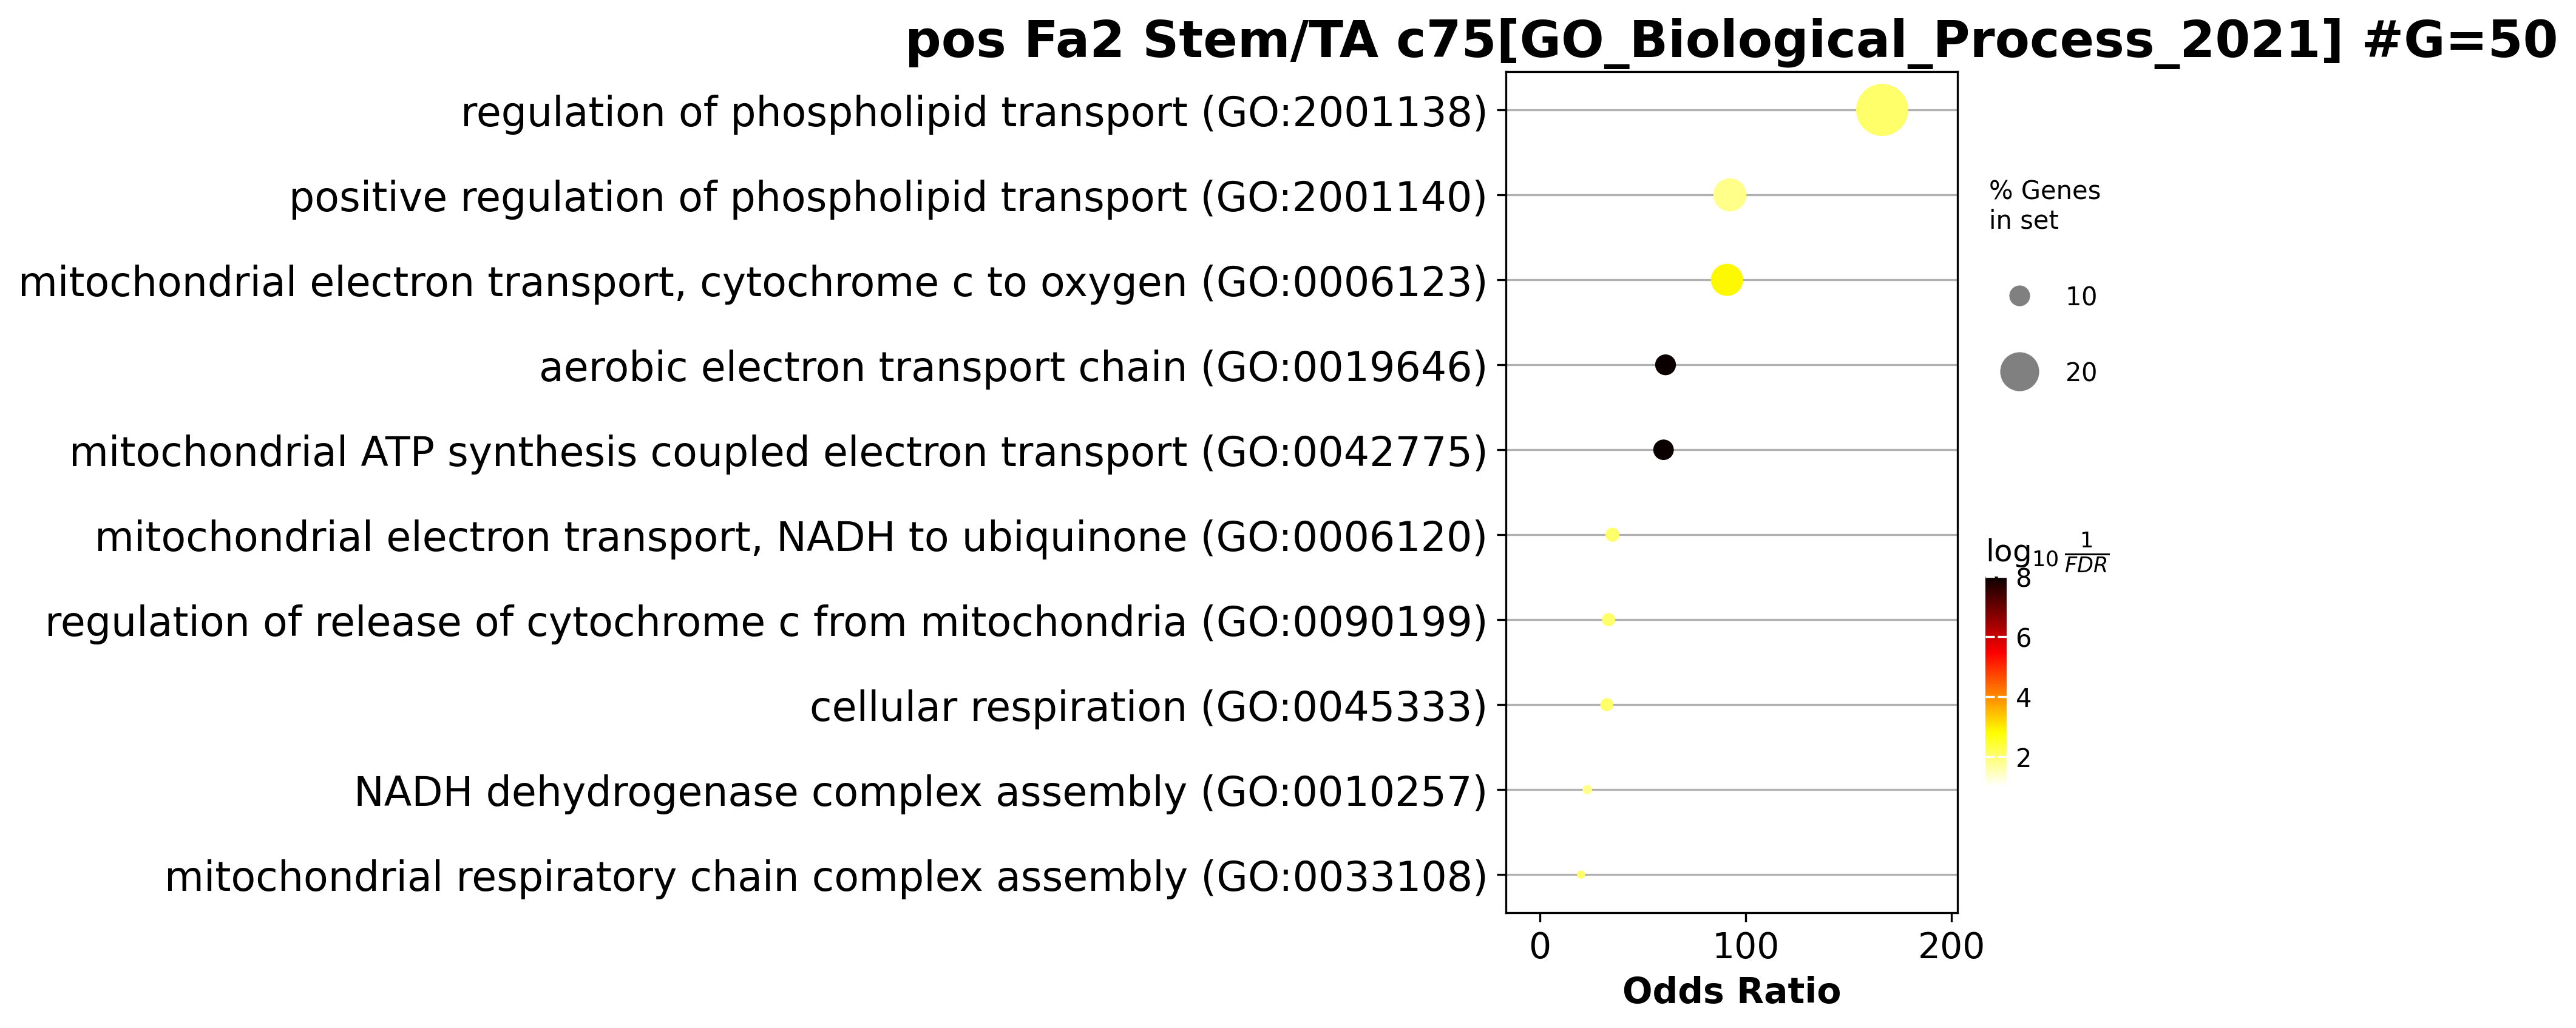

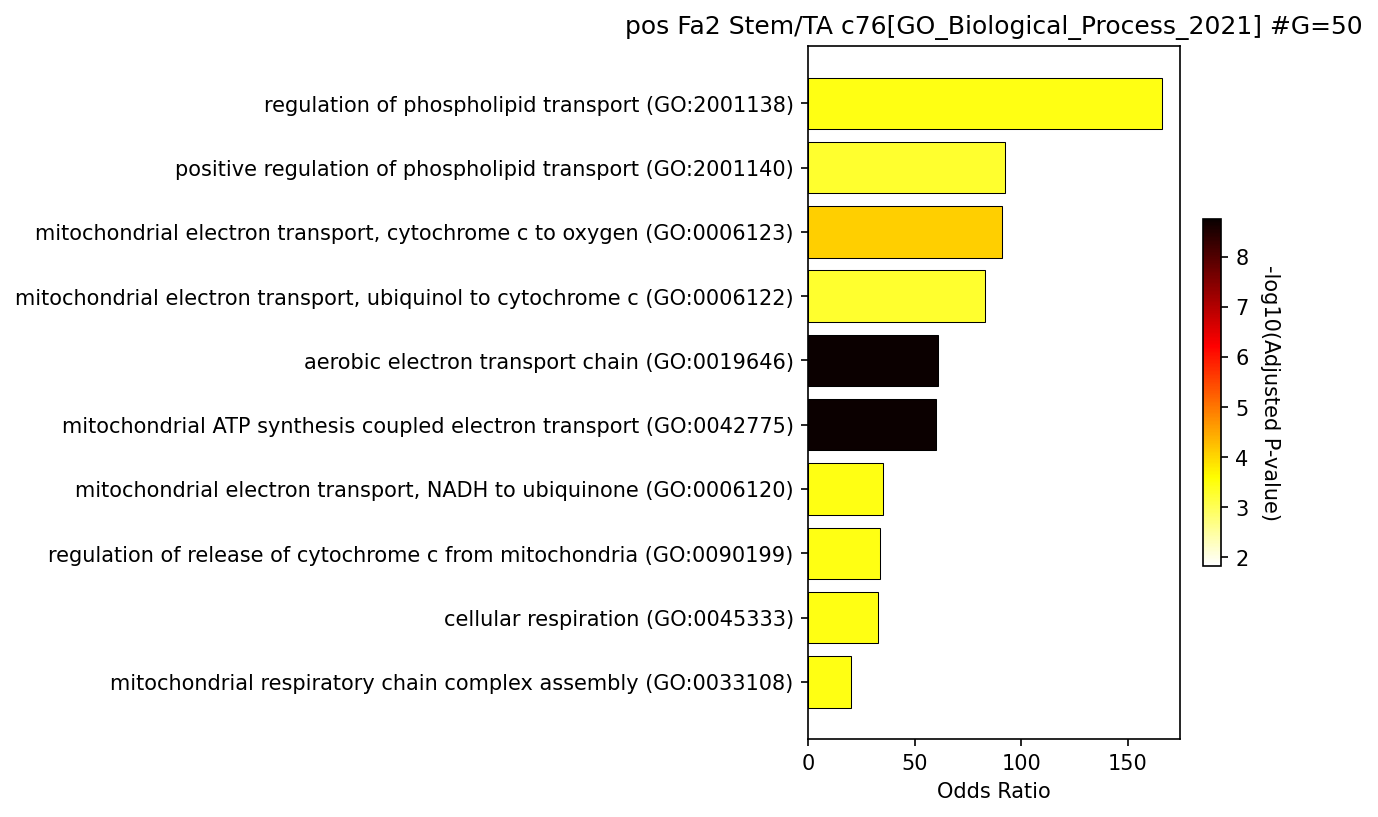

In [ ]:
from nico_wrapper.covariation.reports import run_pathway_enrichment
from nico_wrapper.covariation.config import CovariationReportConfig
from IPython.display import display, Image

pathway_paths = run_pathway_enrichment(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Stem/TA",),
        choose_factors_id=(1,),
        pathway_top_genes=50,
        pathway_databases=("GO_Biological_Process_2021",),
        pathway_plot_as="dotplot",
        positively_correlated=True,
        include_rps_rpl_mt_genes=False,
        organism="Mouse",
        correlation_with_spearman=True,
        show=False,   # display from saved file to ensure inline rendering
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

for p in pathway_paths:
    display(Image(filename=str(p)))

The pathway figures are saved in  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Pathway_figures/
cell types found  ['Stem/TA']


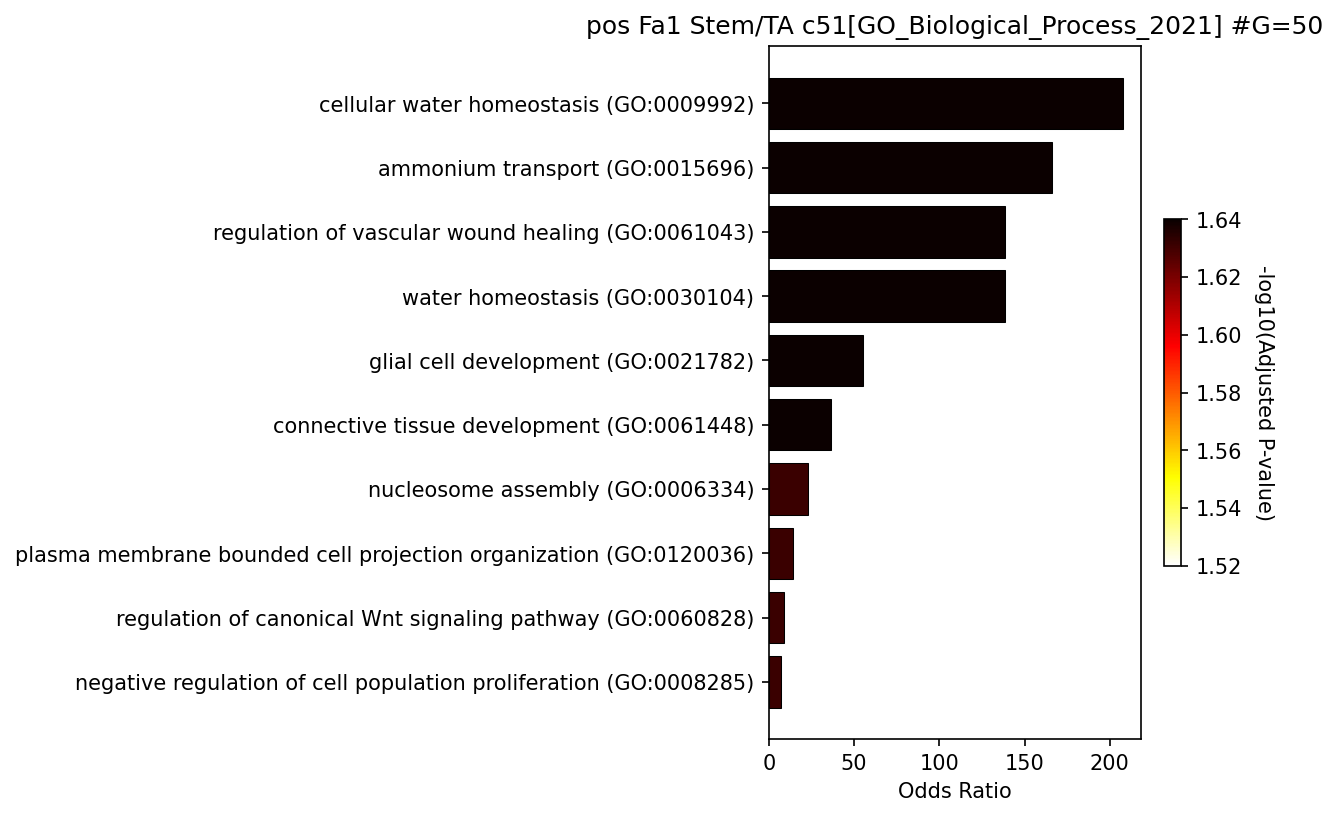

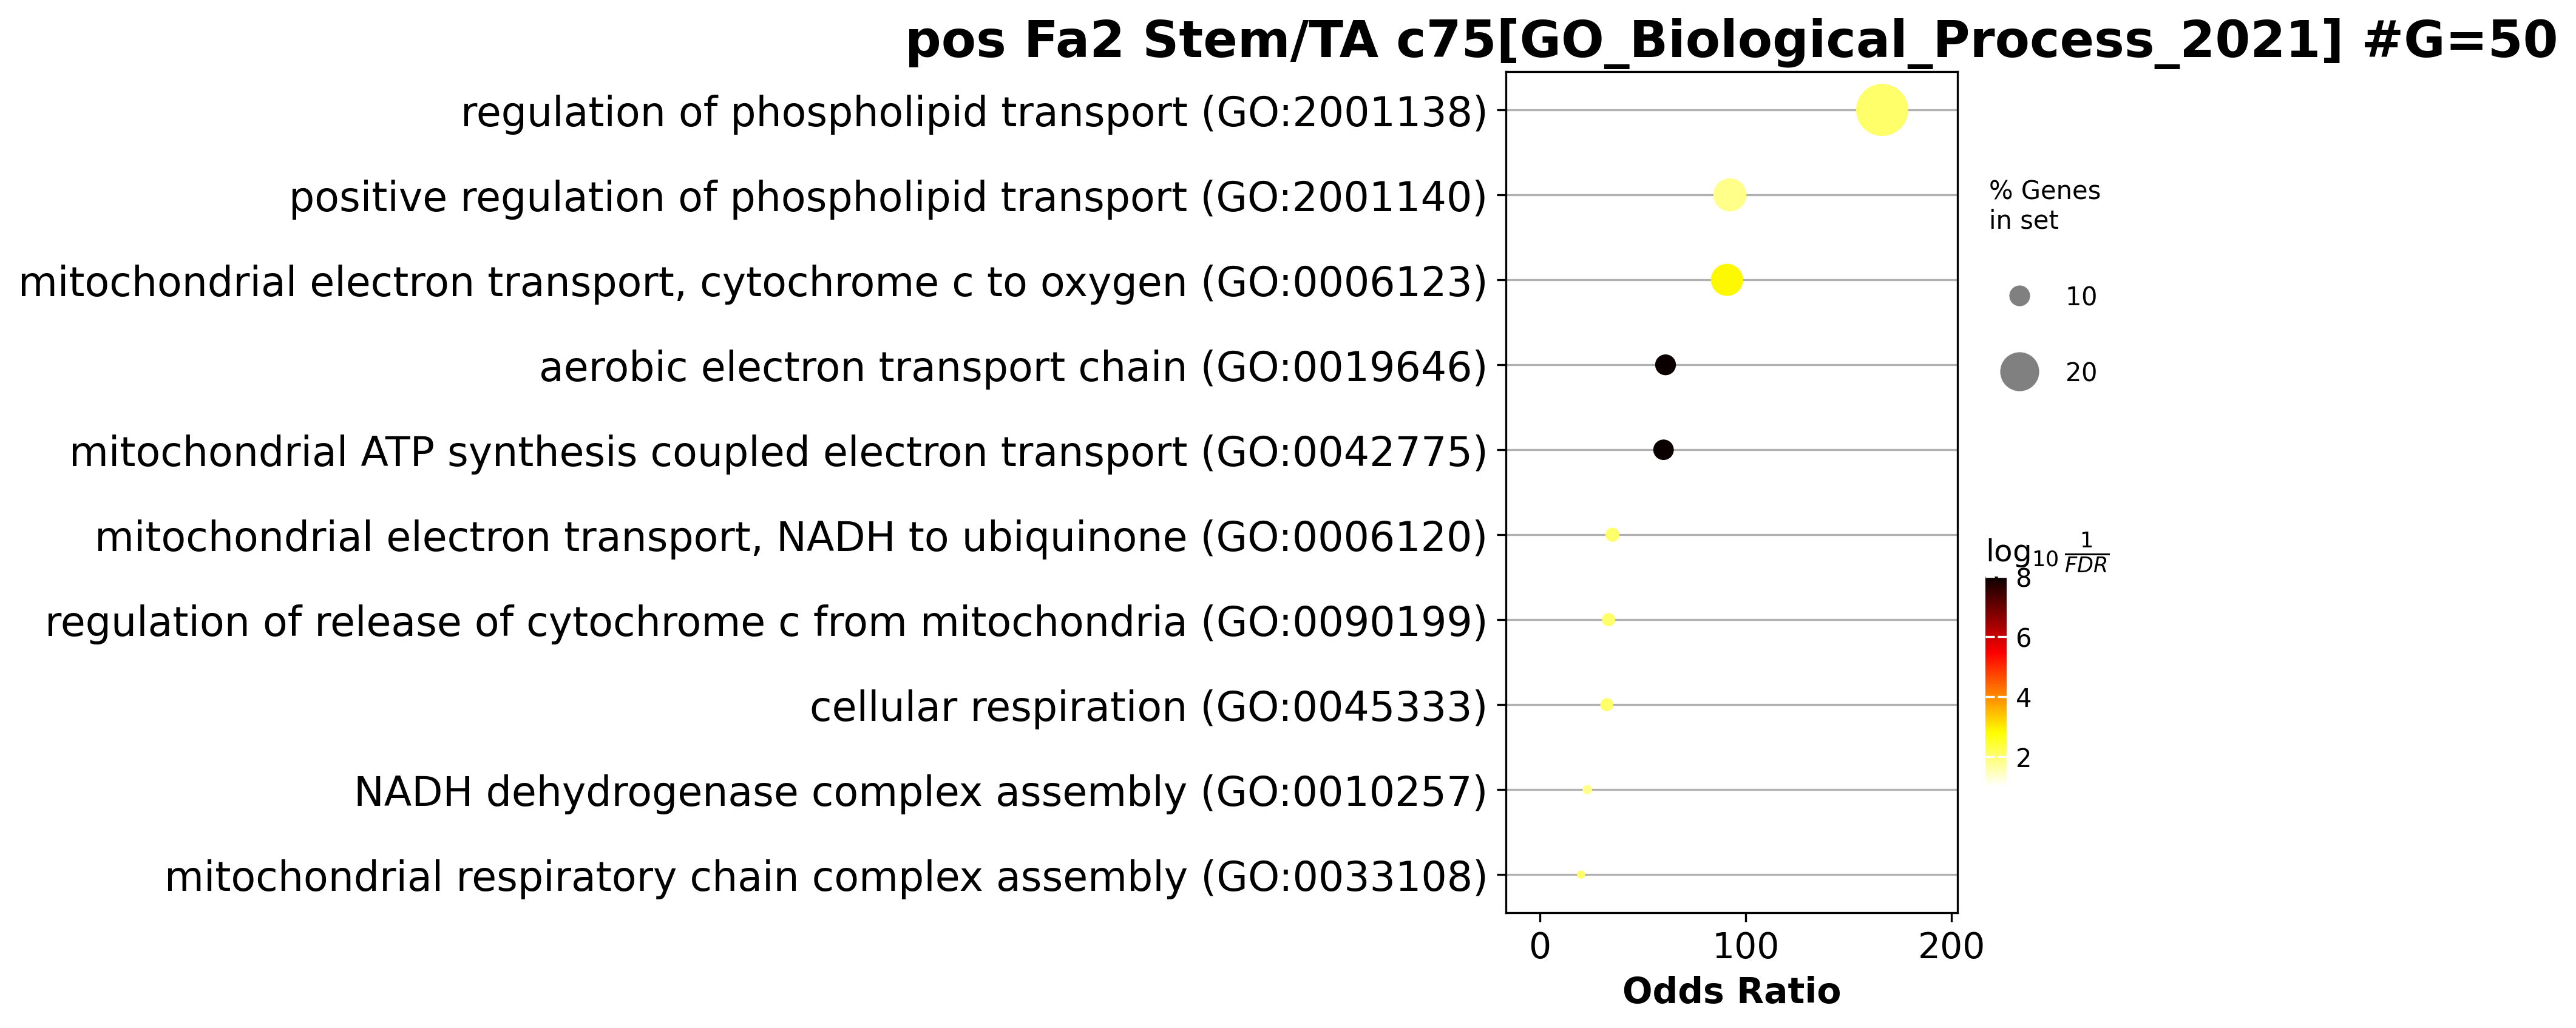

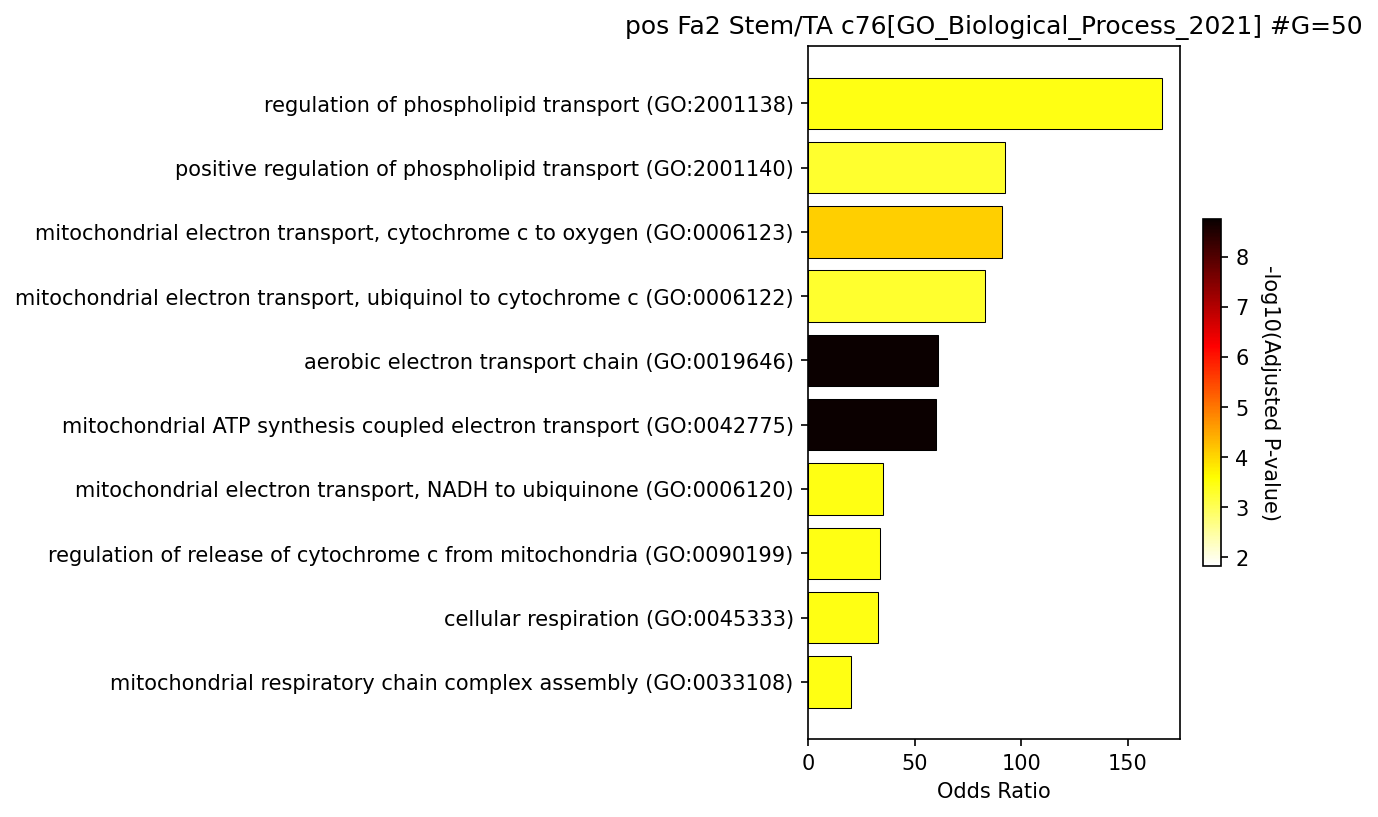

In [ ]:
#Barplot, instead of dotplot
pathway_paths = run_pathway_enrichment(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Stem/TA",),
        choose_factors_id=(1,),
        pathway_top_genes=50,
        pathway_databases=("GO_Biological_Process_2021",),
        pathway_plot_as="barplot",
        positively_correlated=True,
        include_rps_rpl_mt_genes=False,
        organism="Mouse",
        correlation_with_spearman=True,
        show=False,   # display from saved file to ensure inline rendering
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

for p in pathway_paths:
    display(Image(filename=str(p)))

#### Additional plots
Visualization of top genes across cell types and factors as dotplot

cell types found  ['Paneth', 'Stem/TA']
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Paneth.png
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Stem_TA.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Factors_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Paneth.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/combined_Stem_TA_Paneth.png'))

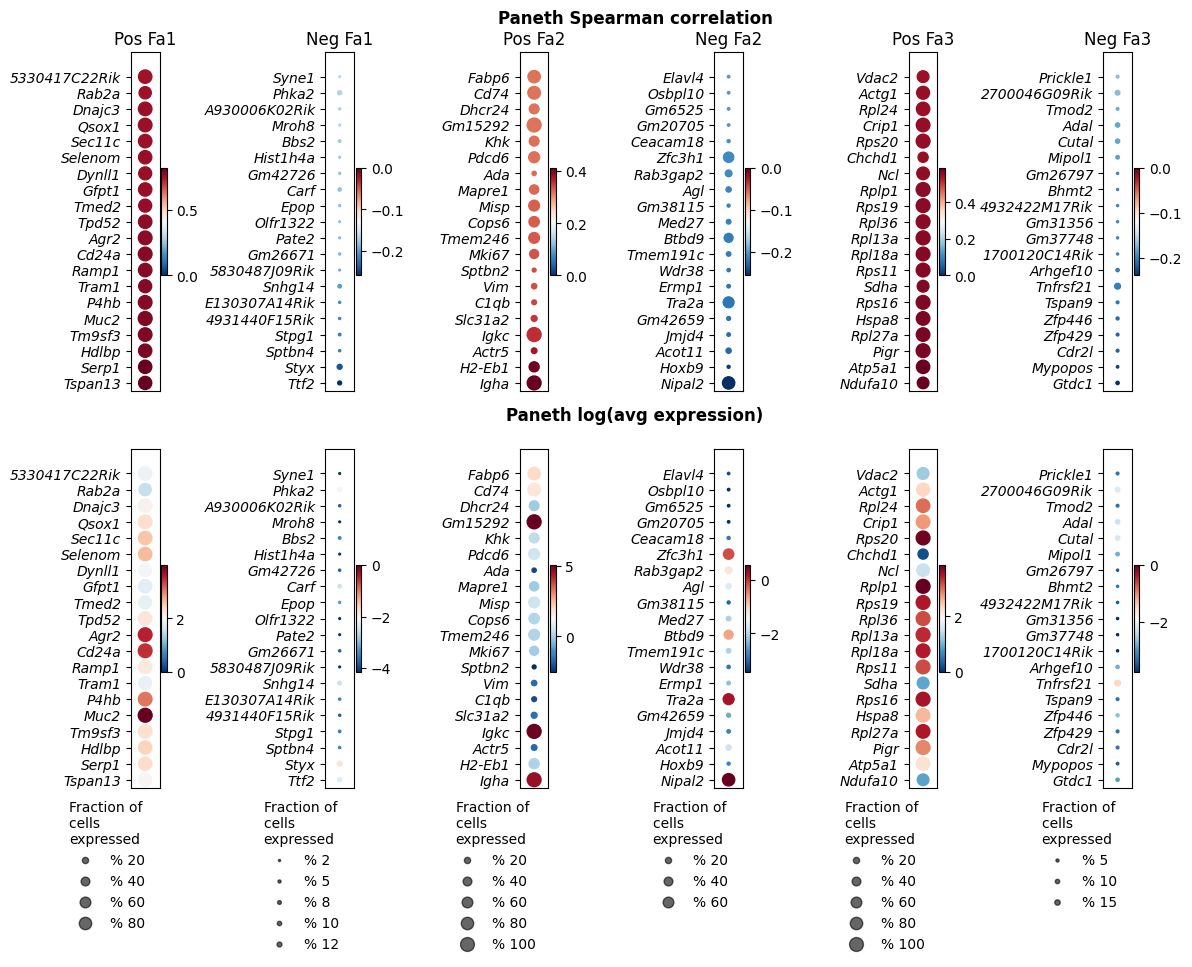

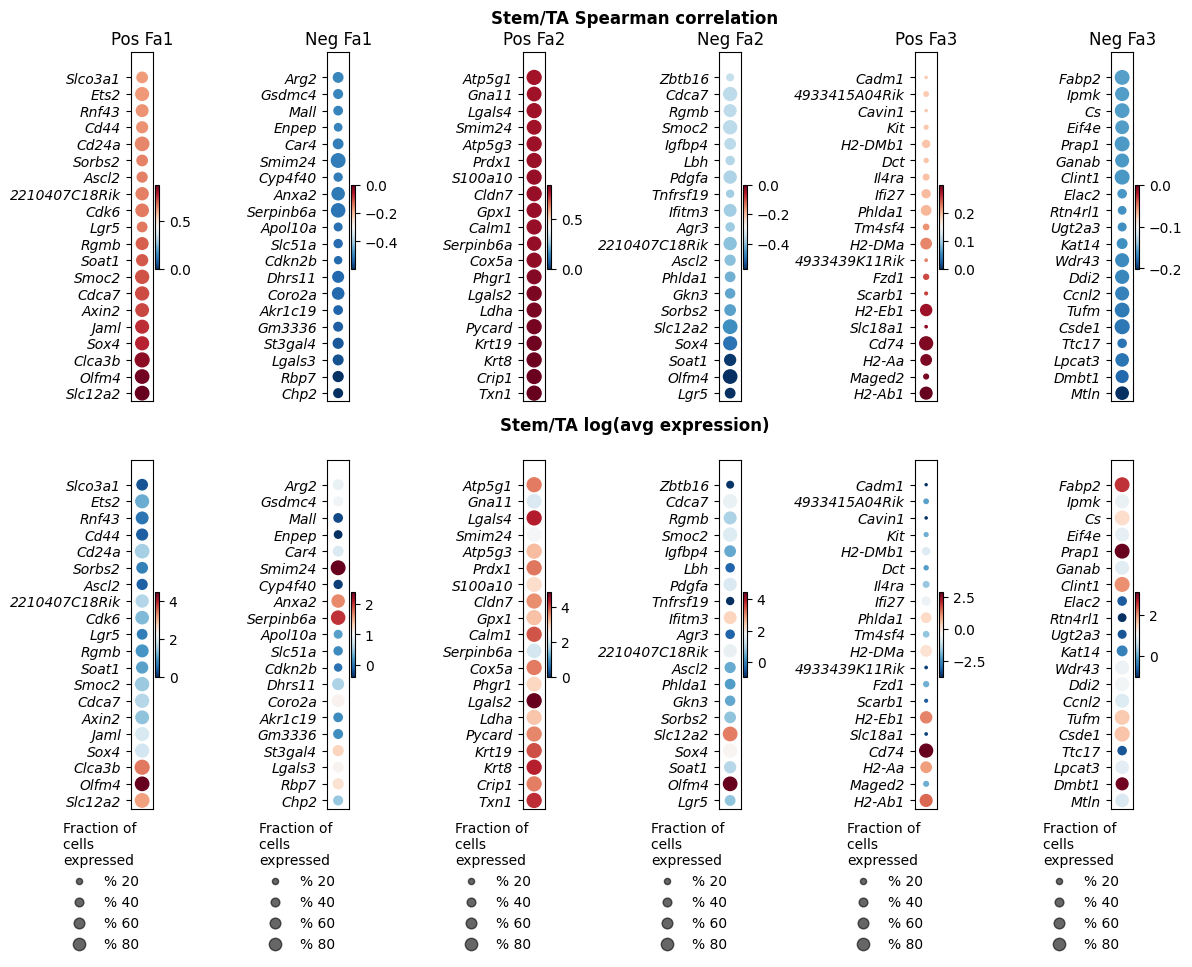

In [ ]:
from nico_wrapper.covariation.reports import plot_top_genes_all_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Top genes per factor for selected cell types (dot plots, one per cell type × factor).
plot_top_genes_all_factors(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Paneth", "Stem/TA"),
        top_genes_per_factor=20,
        organism="Mouse",
        include_rps_rpl_mt_genes=True,
        correlation_with_spearman=True,
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/combined_Stem_TA_Paneth.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Factors_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Paneth.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/combined_Stem_TA_Paneth.png'))

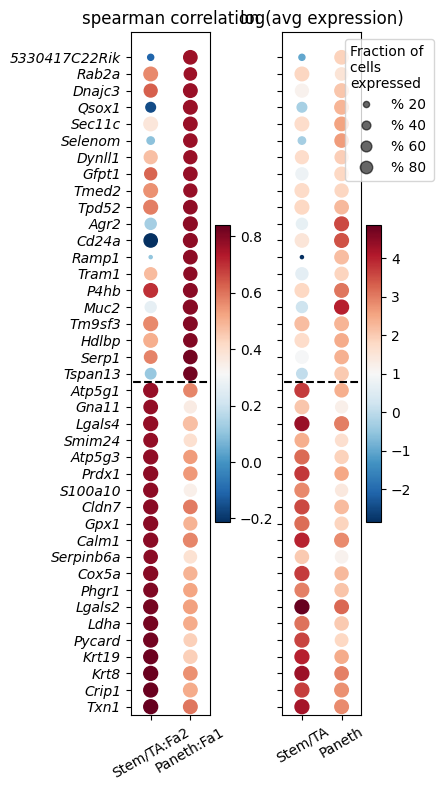

In [ ]:
from nico_wrapper.covariation.reports import plot_top_genes_pair
from nico_wrapper.covariation.config import CovariationReportConfig

# Top genes for a pair of cell types from two chosen factors.
plot_top_genes_pair(
    covariation_result,
    celltype_pair=("Stem/TA", "Paneth"),
    factor_ids=(1, 1),
    config=CovariationReportConfig(
        top_genes_per_factor=20,
        organism="Mouse",
        include_rps_rpl_mt_genes=True,
        correlation_with_spearman=True,
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

Visualization of factor values in the UMAP

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/spatial_factors_in_umap.png


PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/spatial_factors_in_umap.png')

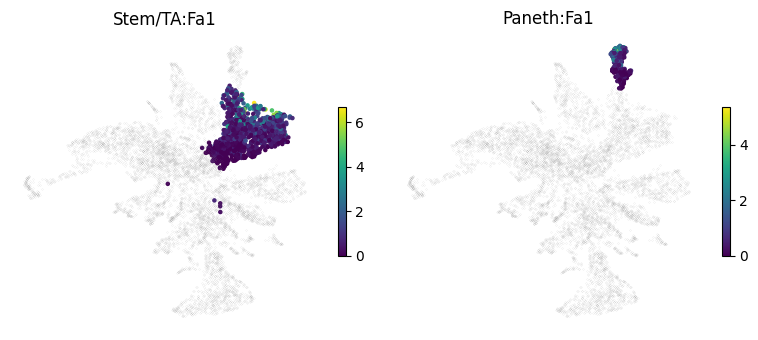

In [ ]:
from nico_wrapper.covariation.reports import plot_factor_umap
from nico_wrapper.covariation.config import CovariationReportConfig

# Spatial UMAP: factor loadings overlaid on spatial coordinates.
plot_factor_umap(
    covariation_result,
    modality="spatial",
    celltype_pair=("Stem/TA", "Paneth"),
    factor_ids=(1, 1),
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png


PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png')

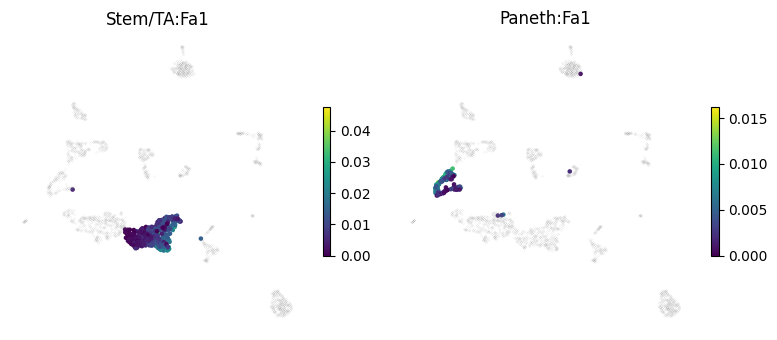

In [ ]:
from nico_wrapper.covariation.reports import plot_factor_umap
from nico_wrapper.covariation.config import CovariationReportConfig

# scRNAseq UMAP: factor loadings overlaid on scRNA-seq UMAP coordinates.
plot_factor_umap(
    covariation_result,
    modality="sc",
    celltype_pair=("Stem/TA", "Paneth"),
    factor_ids=(1, 1),
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

Visualization of one cell type at a time

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/spatial_factors_in_umap.png
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png


PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png')

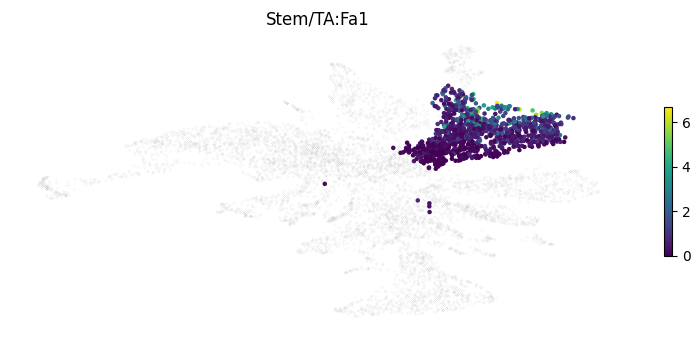

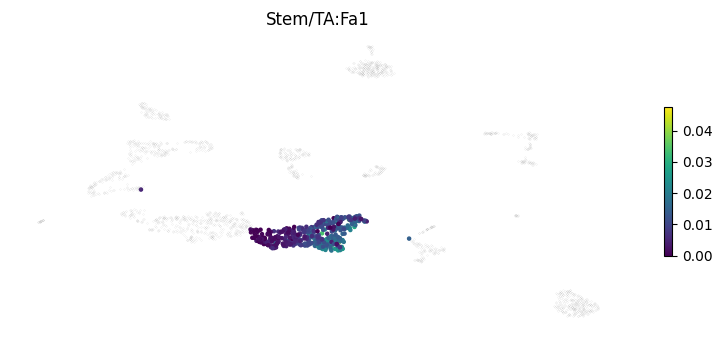

In [ ]:
from nico_wrapper.covariation.reports import plot_factor_umap
from nico_wrapper.covariation.config import CovariationReportConfig

_cfg = CovariationReportConfig(show=True, saveas="png", dpi=150, transparent=False)

# Spatial UMAP: single cell type / single factor.
plot_factor_umap(
    covariation_result,
    modality="spatial",
    celltype_pair=("Stem/TA",),
    factor_ids=(1,),
    config=_cfg,
)

# scRNAseq UMAP: single cell type / single factor.
plot_factor_umap(
    covariation_result,
    modality="sc",
    celltype_pair=("Stem/TA",),
    factor_ids=(1,),
    config=_cfg,
)